## 07_heatmap

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### анализируйте только пользователей, а не администраторов

In [2]:
checker = pd.read_sql(
    """
        SELECT uid, timestamp
        FROM checker
        WHERE uid LIKE 'user_%' 
    """,
    conn,
    parse_dates="timestamp",
)
checker["hour"] = checker.timestamp.dt.hour
checker["weekday"] = checker.timestamp.dt.day_name()
checker

,uid,timestamp,hour,weekday
0,user_4,2020-04-17 05:19:02.744528,5,Friday
1,user_4,2020-04-17 05:22:35.249331,5,Friday
2,user_4,2020-04-17 05:22:45.549397,5,Friday
3,user_4,2020-04-17 05:34:14.691200,5,Friday
4,user_4,2020-04-17 05:34:24.422370,5,Friday
...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,20,Thursday
3203,user_1,2020-05-21 20:22:41.785725,20,Thursday
3204,user_1,2020-05-21 20:22:41.877806,20,Thursday
3205,user_1,2020-05-21 20:37:00.129678,20,Thursday


### используйте абсолютные значения коммитов, а не средние значения, сортируйте фреймы данных по общему количеству коммитов, сделанных пользователем

In [3]:
columns = checker.groupby("uid").count().sort_values("hour", ascending=False).index
columns

Index(['user_4', 'user_14', 'user_2', 'user_25', 'user_19', 'user_26',
       'user_20', 'user_31', 'user_10', 'user_3', 'user_29', 'user_13',
       'user_28', 'user_24', 'user_12', 'user_8', 'user_1', 'user_21',
       'user_30', 'user_18', 'user_17', 'user_16', 'user_27', 'user_15',
       'user_6', 'user_11', 'user_7', 'user_22', 'user_23', 'user_0'],
      dtype='object', name='uid')

In [4]:
df = checker.groupby("uid")["weekday"].value_counts().unstack(0)
df = df.reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)
df = df.reindex(columns=columns)
df = df.fillna(0)
df

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
weekday,,,,,,,,,,,,,,,,,,,,,
Monday,35.0,50.0,24.0,14.0,7.0,0.0,23.0,5.0,0.0,46.0,...,8.0,10.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,3.0
Tuesday,86.0,87.0,131.0,44.0,9.0,1.0,0.0,0.0,16.0,11.0,...,4.0,5.0,0.0,0.0,0.0,0.0,5.0,3.0,0.0,0.0
Wednesday,33.0,0.0,32.0,15.0,0.0,34.0,8.0,0.0,37.0,0.0,...,1.0,0.0,0.0,0.0,4.0,0.0,3.0,0.0,0.0,0.0
Thursday,108.0,17.0,4.0,40.0,78.0,51.0,96.0,7.0,77.0,7.0,...,17.0,14.0,15.0,5.0,2.0,0.0,0.0,2.0,6.0,0.0
Friday,61.0,0.0,0.0,10.0,10.0,2.0,7.0,35.0,1.0,59.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Saturday,0.0,79.0,31.0,66.0,21.0,16.0,3.0,90.0,4.0,3.0,...,32.0,0.0,0.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0
Sunday,45.0,26.0,13.0,44.0,51.0,69.0,28.0,7.0,2.0,8.0,...,0.0,31.0,27.0,20.0,9.0,8.0,0.0,1.0,0.0,0.0


In [5]:
df_hour = checker.groupby("uid").hour.value_counts().unstack(0)
df_hour = df_hour.reindex(index=pd.RangeIndex(24), fill_value=0)
df_hour = df_hour.reindex(columns=columns)
df_hour = df_hour.rename_axis("hour")
df_hour = df_hour.fillna(0)
df_hour

uid,user_4,user_14,user_2,user_25,user_19,user_26,user_20,user_31,user_10,user_3,...,user_17,user_16,user_27,user_15,user_6,user_11,user_7,user_22,user_23,user_0
hour,,,,,,,,,,,,,,,,,,,,,
0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
1,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,13.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,3.0,6.0,0.0,0.0,10.0,2.0,0.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,6.0,0.0,0.0,0.0,5.0,2.0,0.0,9.0,6.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


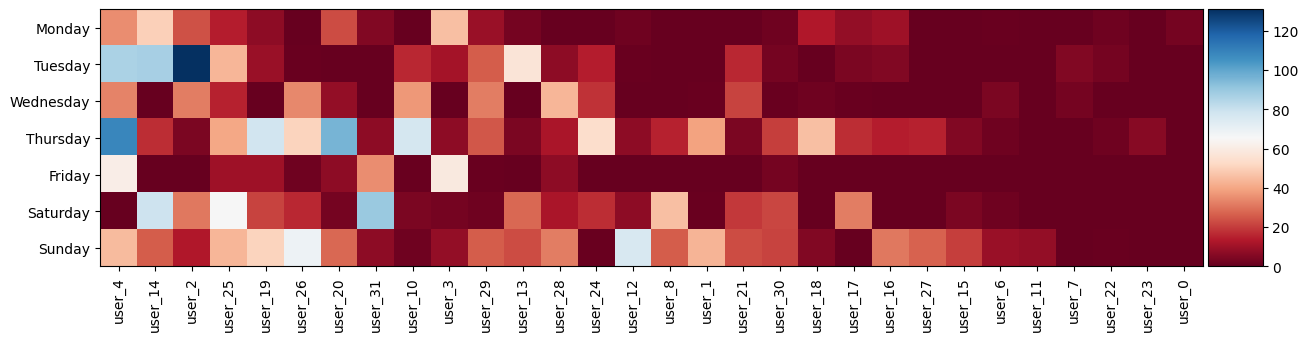

In [6]:
fig, ax = plt.subplots(figsize=(15, 8))
im = ax.imshow(df, cmap="RdBu")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
ax.set_xticks(range(df.shape[1]))
ax.set_yticks(range(df.shape[0]))
ax.set_xticklabels(df.columns)
ax.set_yticklabels(df.index)
plt.setp(ax.get_xticklabels(), rotation=90)
plt.show()

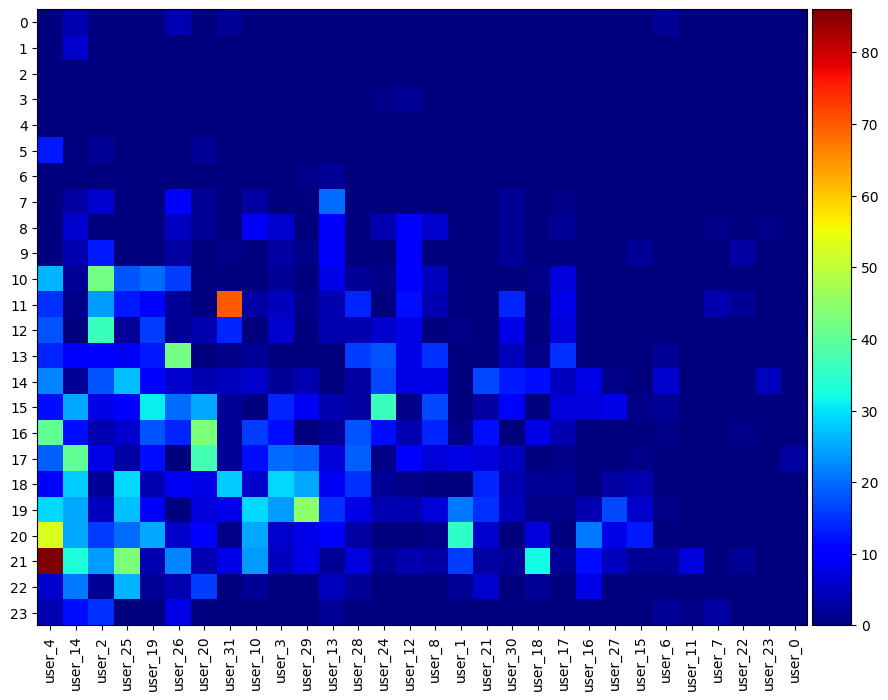

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))
im = ax.imshow(df_hour, cmap="jet")
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(im, cax=cax)
ax.set_xticks(range(df_hour.shape[1]))
ax.set_yticks(range(df_hour.shape[0]))
ax.set_xticklabels(df_hour.columns)
ax.set_yticklabels(df_hour.index)
plt.setp(ax.get_xticklabels(), rotation=90)
plt.show()

### У какого пользователя больше всего коммитов во вторник? Ответ - user_2.

### У какого пользователя больше всего коммитов в четверг? Ответ - user_4.

### В какой день недели пользователи не любят делать много коммитов? Ответ - пятница.

### Какой пользователь в какой час сделал наибольшее количество коммитов? Ответ - user_4 в 21 час.

In [8]:
conn.close()